In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.impute import MissingIndicator
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from IPython.display import Image
%matplotlib inline
sns.set(style="ticks")
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import *
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(style="ticks")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
drive_file_path = "/content/drive/MyDrive/synthetic_coffee_health_10000.csv"
data = pd.read_csv("/content/drive/MyDrive/synthetic_coffee_health_10000.csv")
data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


In [ ]:
data.shape
data.columns
data.dtypes

,0
ID,int64
Age,int64
Gender,object
Country,object
Coffee_Intake,float64
Caffeine_mg,float64
Sleep_Hours,float64
Sleep_Quality,object
BMI,float64
Heart_Rate,int64


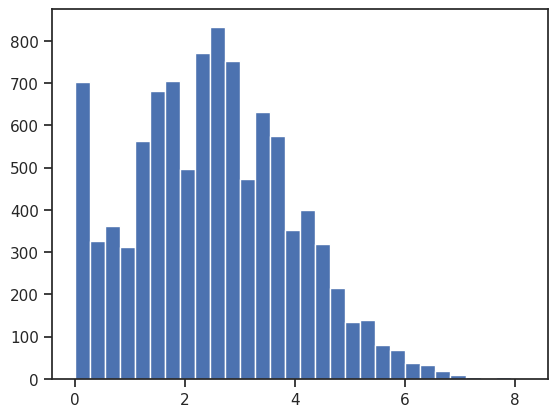

In [ ]:
sc1 = MinMaxScaler()
sc1_data = sc1.fit_transform(data[['Coffee_Intake']])
plt.hist(data['Coffee_Intake'], 30)
plt.show()

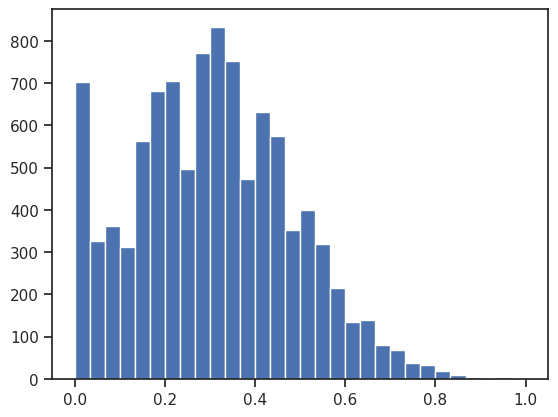

In [ ]:
plt.hist(sc1_data, 30)
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
cat_enc = data['Stress_Level']
cat_enc
cat_enc.unique()

array(['Low', 'Medium', 'High'], dtype=object)

In [ ]:
le = LabelEncoder()
cat_enc_le = le.fit_transform(cat_enc)
cat_enc_le
le.classes_
np.unique(cat_enc_le)

array([0, 1, 2])

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
data_oe = data[['Stress_Level','Health_Issues']]
data_oe.head()

,Stress_Level,Health_Issues
0,Low,NaN
1,Low,NaN
2,Medium,Mild
3,Low,Mild
4,Medium,Mild


In [ ]:
imp4 = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='NA')
data_oe_filled = imp4.fit_transform(data_oe)
data_oe_filled

array([['Low', 'NA'],
       ['Low', 'NA'],
       ['Medium', 'Mild'],
       ...,
       ['Low', 'NA'],
       ['Low', 'NA'],
       ['Low', 'NA']], dtype=object)

In [ ]:
oe = OrdinalEncoder()
cat_enc_oe = oe.fit_transform(data_oe_filled)
cat_enc_oe

array([[1., 2.],
       [1., 2.],
       [2., 0.],
       ...,
       [1., 2.],
       [1., 2.],
       [1., 2.]])

In [ ]:
np.unique(cat_enc_oe[:, 0])

array([0., 1., 2.])